In [205]:
import pandas as pd
import warnings
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Import and overall overview of the dataset

In [206]:
df = pd.read_csv(r'insurance.csv')
df.head(2)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523


In [207]:
df.tail(2)

,age,sex,bmi,children,smoker,region,charges
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [208]:
smoker_palette = {'yes': 'lightcoral', 'no': 'skyblue'}

In [209]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


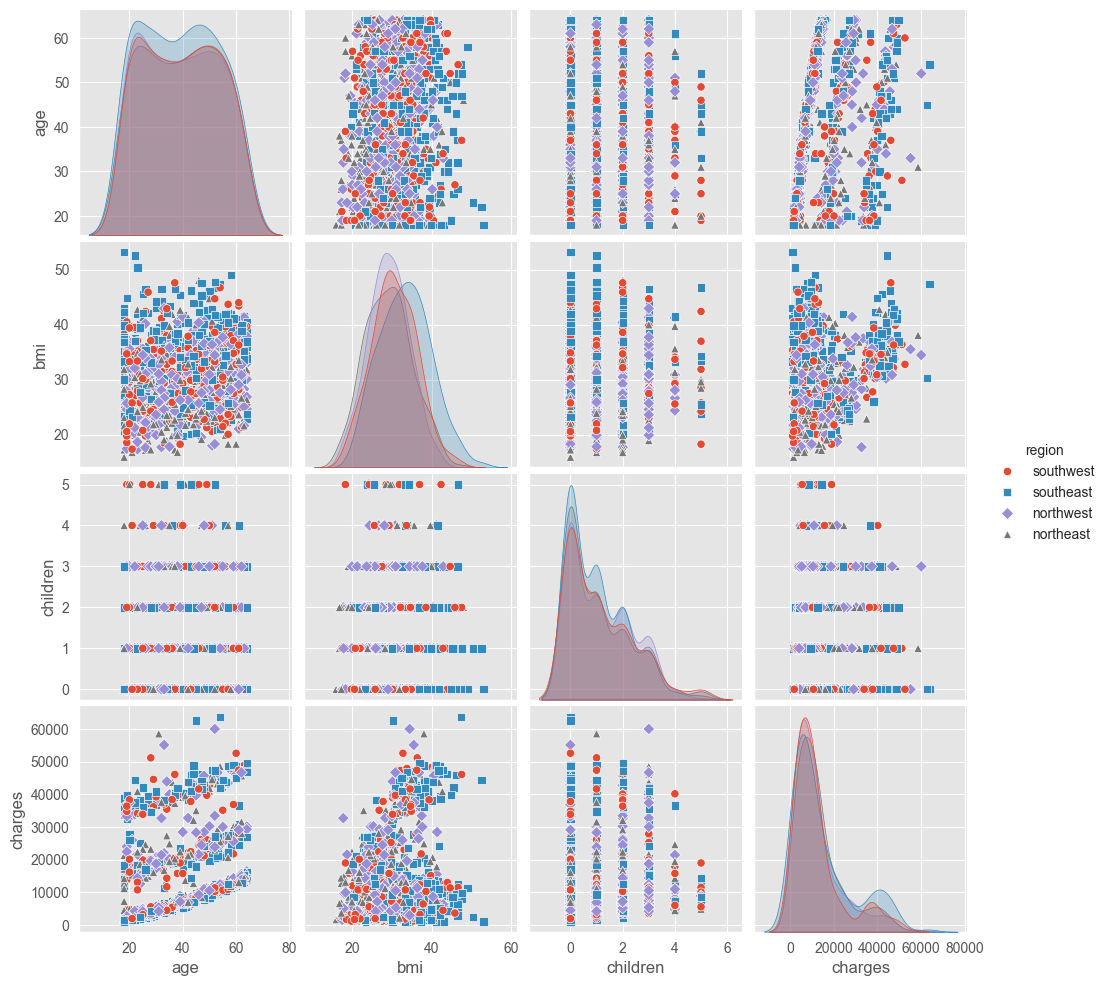

In [210]:
plt.style.use('ggplot')
sns.pairplot(df, hue = 'region', diag_kind = 'kde', markers = ['o', 's', 'D', '^'])
plt.show()

# Handling the outliers

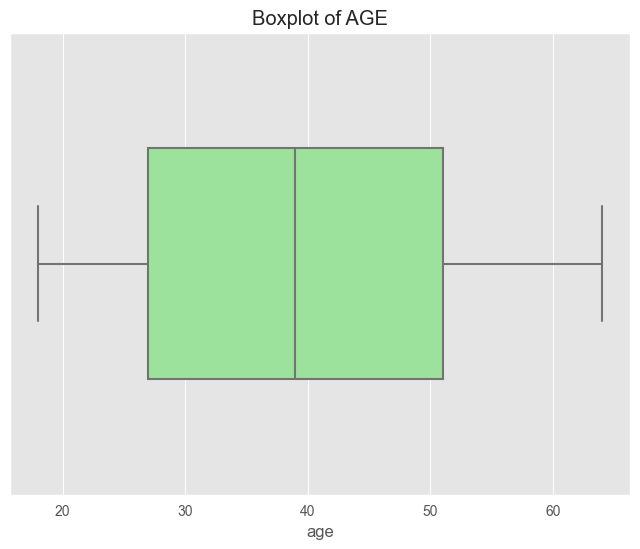

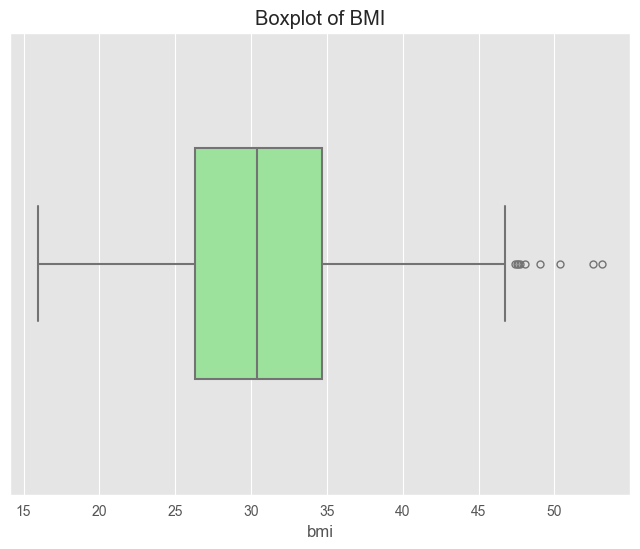

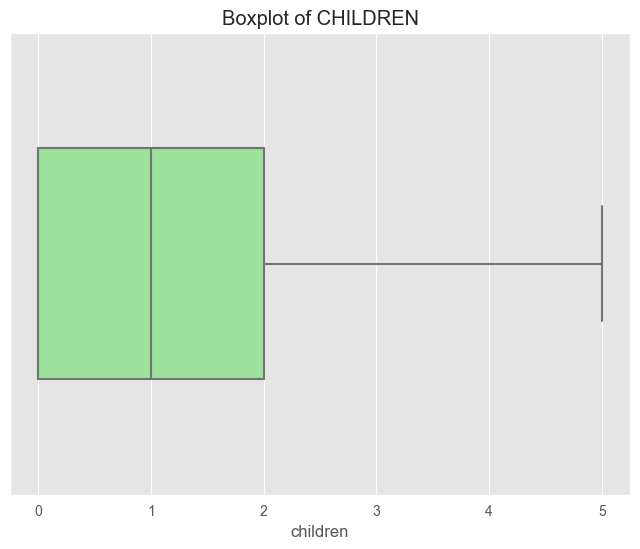

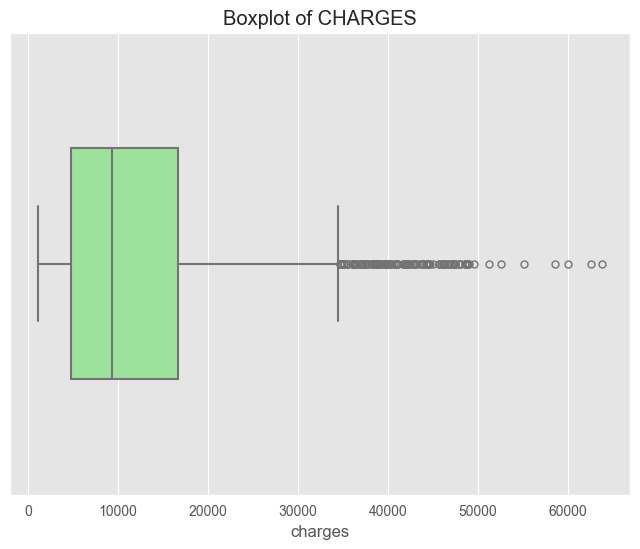

In [211]:
for i in df.select_dtypes('number').columns:
    plt.figure(figsize=(8, 6))
    plt.style.use('ggplot')
    sns.boxplot(x=df[i], color='lightgreen', width=0.5, fliersize=5, linewidth=1.5)
    plt.title(f'Boxplot of {i.upper()}')

In [212]:

for i in df.select_dtypes('number').columns:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_condition = (df[i] < lower_bound) | (df[i] > upper_bound)
    print(f'{df[i].isin(outlier_condition).value_counts(normalize=True)}')
    
    


age
False    1.0
Name: proportion, dtype: float64
bmi
False    1.0
Name: proportion, dtype: float64
children
False    0.571001
True     0.428999
Name: proportion, dtype: float64
charges
False    1.0
Name: proportion, dtype: float64


The output shows none of the variables bmi, charges have any outliers which means that there are ano outliers that fall under the condition of being more than 1.5 times the interquartile range (IQR) above the third quartile or below the first quartile for the bmi, charges variables. Children is a special case as it has outliers but it was considered as a categorical variable in our dataset, so we are not cosidering it for outlier analysis.

# Age wise classification and categorization of smokers and non-smokers

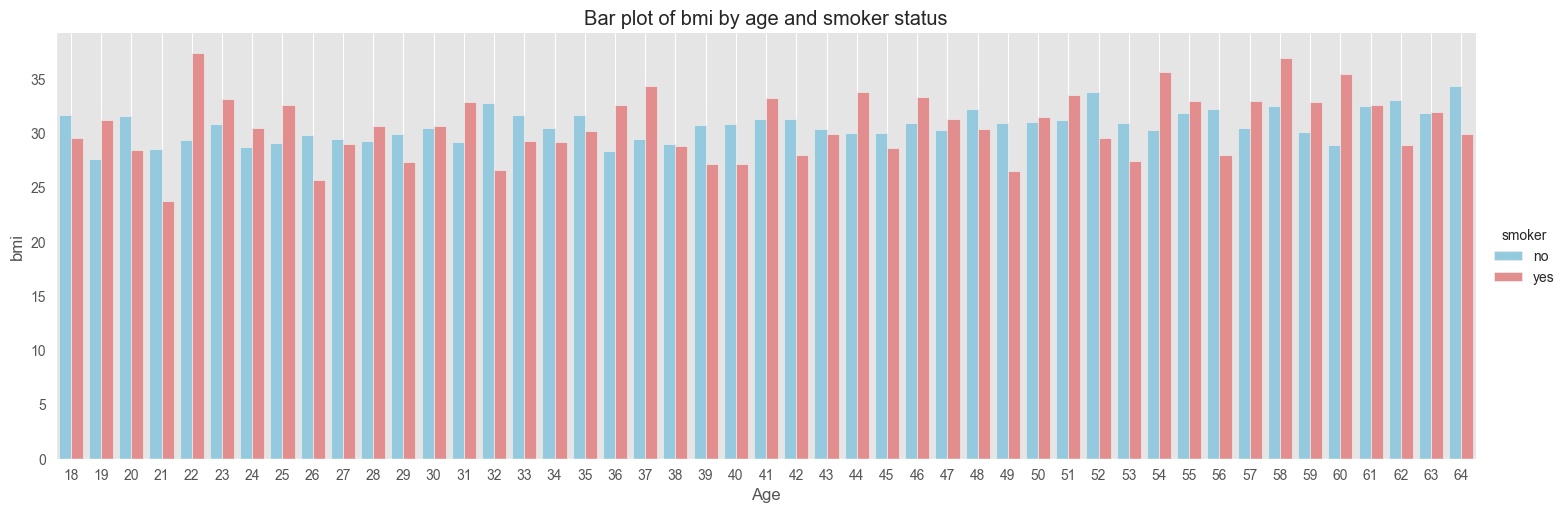

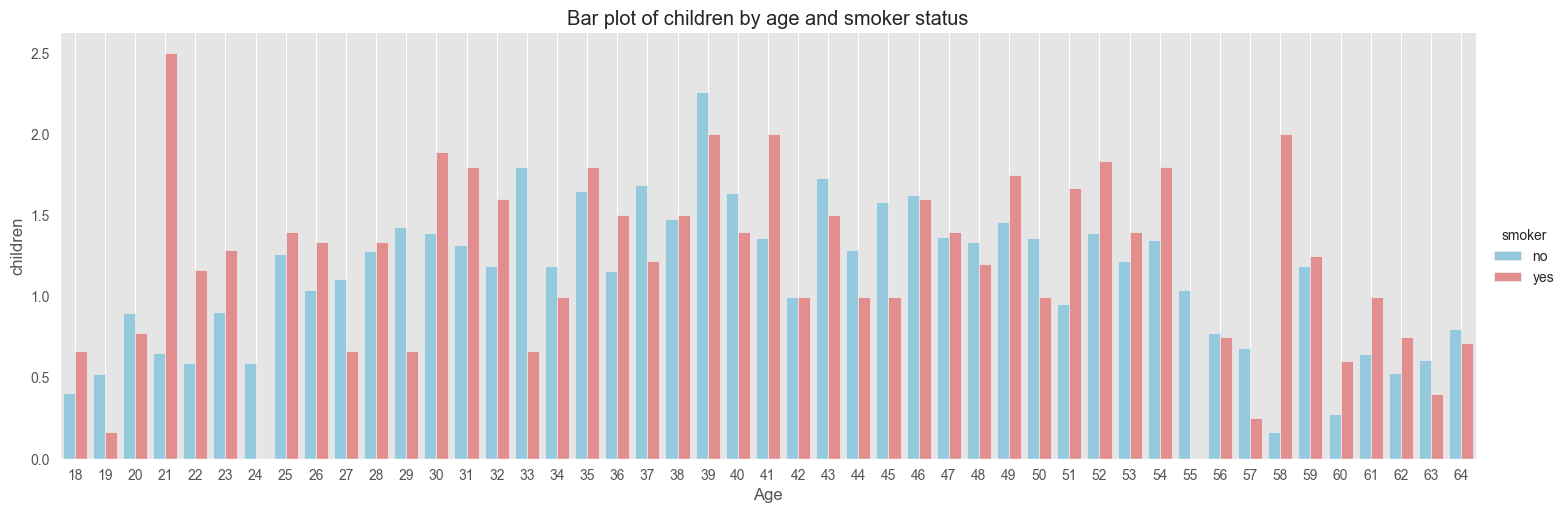

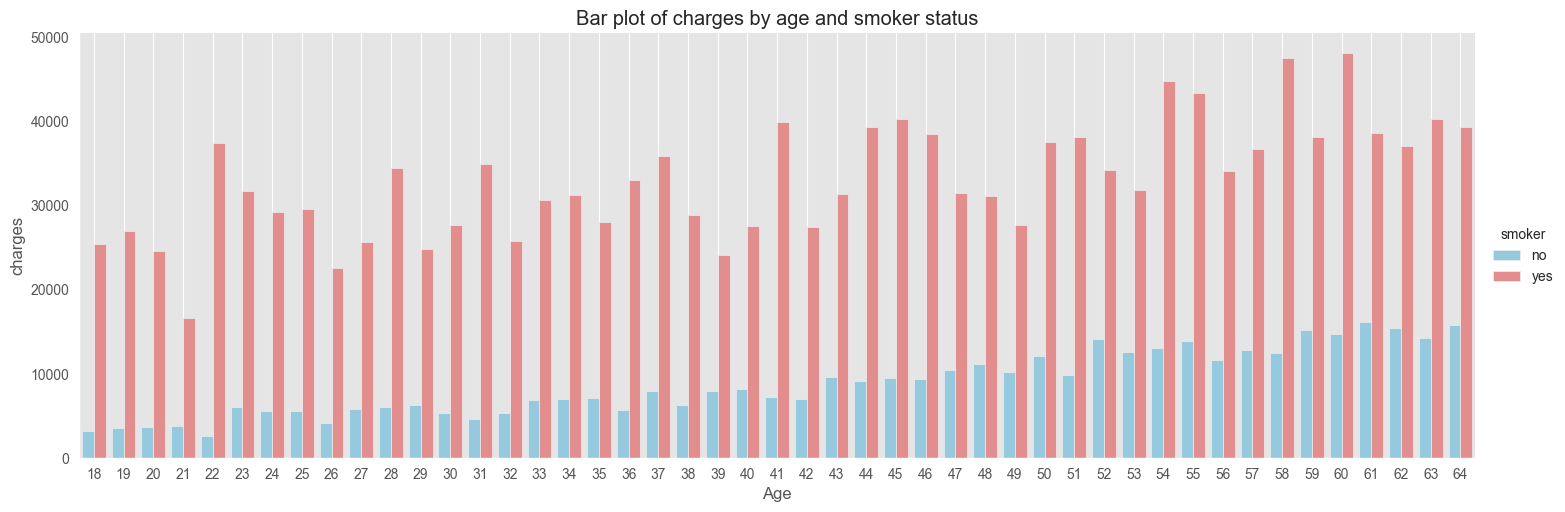

In [213]:
for i in df.select_dtypes('number').columns.drop(['age']):
    plt.style.use('ggplot')
    sns.catplot(x="age", y=i, data=df, hue='smoker', kind='bar', aspect=3, errorbar=None, palette=smoker_palette)
    plt.title(f'Bar plot of {i} by age and smoker status')
    plt.xlabel('Age')
    plt.ylabel(i)
    plt.grid()
    plt.title(f'Bar plot of {i} by age and smoker status')
    plt.show()

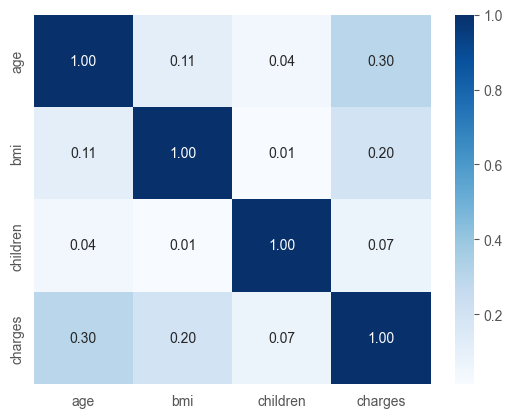

In [214]:
plt.style.use('ggplot')
sns.heatmap(df.select_dtypes('number').corr(), annot=True, cmap='Blues', fmt='.2f')
plt.show()

In [215]:
smoker_analysis = df.groupby('smoker')[['bmi', 'charges']].agg(['mean', 'median', 'std']).reset_index()
smoker_analysis

smoker        bmi                          charges               \
               mean   median       std          mean       median   
0     no  30.651795  30.3525  6.043111   8434.268298   7345.40530   
1    yes  30.708449  30.4475  6.318644  32050.231832  34456.34845   

                 
            std  
0   5993.781819  
1  11541.547176

Smokers usually have higher living cost than non-smokers, so we can visualize the relationship between age, smoker status, and other numerical features in the dataset. The following code generates bar plots for each numerical feature against age, colored by smoker status. On the other hand smoker and non-smoker doesn't have any significant difference in their bmi, so we can say that bmi is not a good parameter to differentiate between smokers and non-smokers. 

```python


In [216]:
df.isna().sum() # a perfect data

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# Region Wise Analaysis

In [217]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

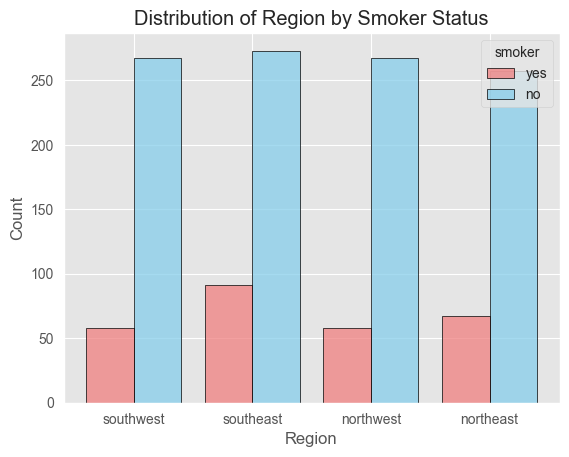

In [218]:
plt.style.use('ggplot')
sns.histplot(data=df, x='region', hue='smoker', multiple='dodge', shrink=0.8, edgecolor='black', palette=smoker_palette)
plt.title('Distribution of Region by Smoker Status')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

In [219]:
region_analysis = df.groupby('region')['charges'].agg(['mean', 'median', 'std']).reset_index()
region_analysis

,region,mean,median,std
0,northeast,13406.384516,10057.652025,11255.803066
1,northwest,12417.575374,8965.795750,11072.276928
2,southeast,14735.411438,9294.131950,13971.098589
3,southwest,12346.937377,8798.593000,11557.179101


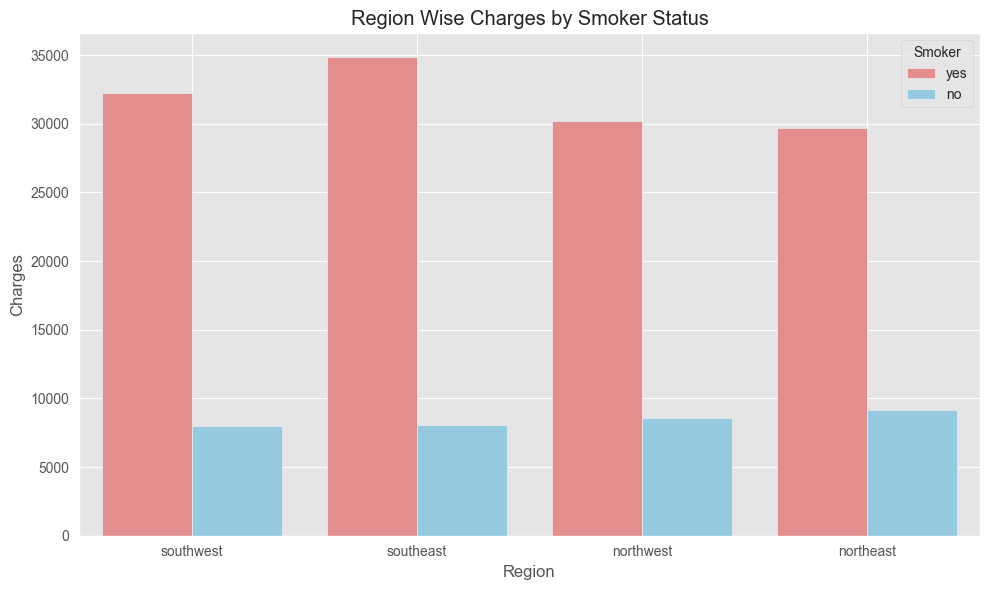

In [220]:
plt.figure(figsize=(10, 6))
plt.style.use('ggplot')
sns.barplot(data=df, x='region', y='charges', ci = None, hue = 'smoker', palette=smoker_palette) 
plt.title('Region Wise Charges by Smoker Status')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.legend(title='Smoker')
plt.grid(True) 
plt.tight_layout() 
plt.show()

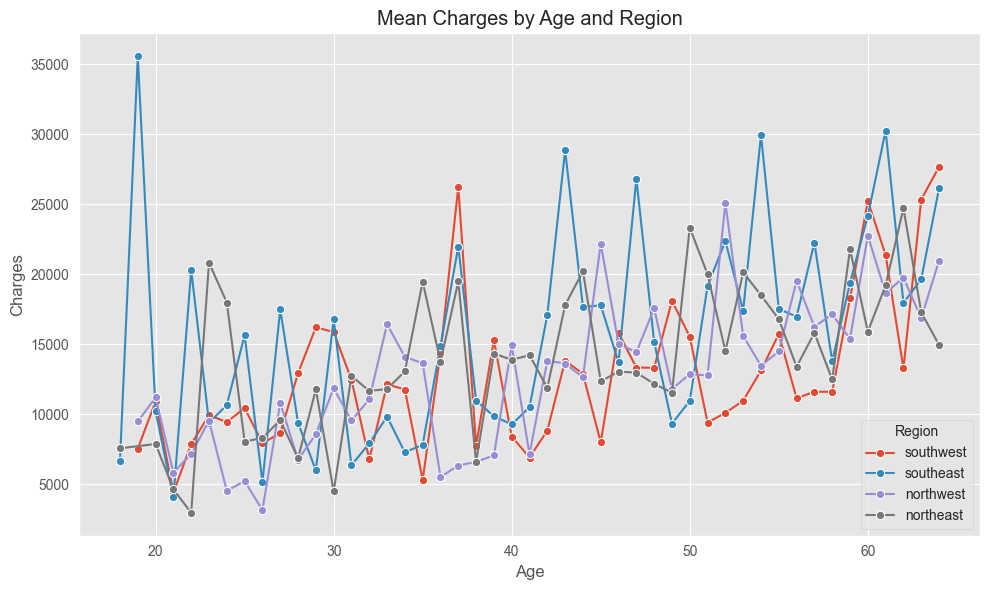

In [221]:
plt.figure(figsize=(10, 6))
plt.style.use('ggplot')
sns.lineplot(data=df, x='age', y='charges', marker='o', hue = 'region', ci = None) 
plt.title('Mean Charges by Age and Region')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend(title='Region')
plt.grid(True) 
plt.tight_layout() 
plt.show()

Region doesn't dispute the data in any significant way, so we can visualize the relationship between age, region, and other numerical features in the dataset. The following code generates bar plots for each numerical feature against age, colored by region.


# Smoker

In [222]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

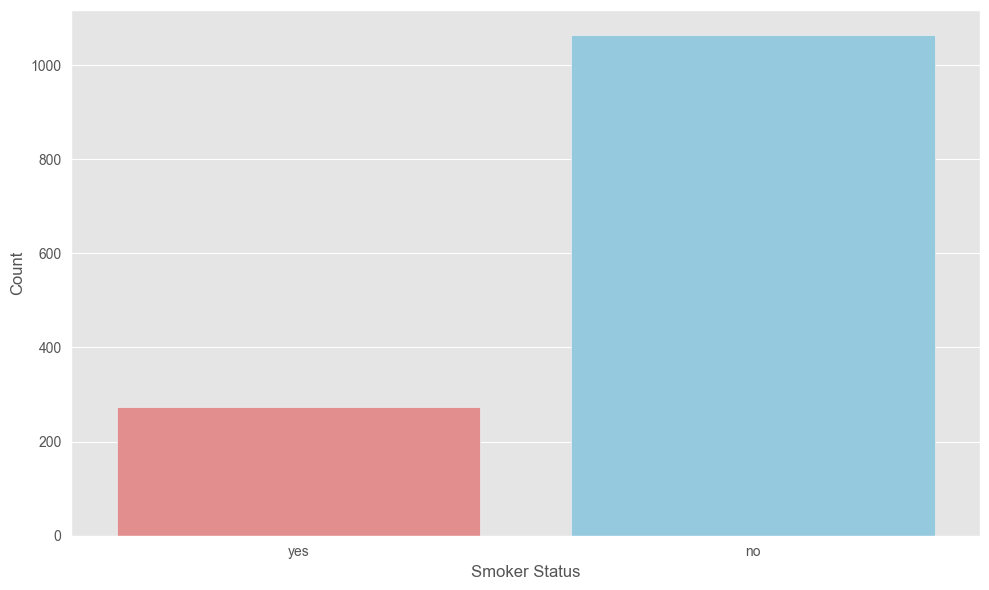

In [223]:
plt.figure(figsize=(10, 6))
plt.style.use('ggplot')
sns.countplot(data=df, x='smoker', palette=smoker_palette)
plt.tight_layout()
plt.xlabel('Smoker Status')
plt.ylabel('Count')
plt.show()

Despite non-smokers are outnumbering the smokers, we can see that the charges for smokers are significantly higher than non-smokers. So smokers plays an important role in the prediction of charges.

# Considering Health Conditions

In [224]:
df['health_condition'] = np.select(
    [
        (df['bmi'] < 18.5),  # Underweight
        (df['bmi'] >= 18.5) & (df['bmi'] < 24.9),
        (df['bmi'] >= 24.9) & (df['bmi'] < 29.9),
        (df['bmi'] >= 29.9) & (df['bmi'] < 34.9),
        (df['bmi'] >= 34.9) & (df['bmi'] < 39.9),
        (df['bmi'] >= 39.9)  
    ],
    [
        'Underweight',   'Normal weight', 'Overweight', 'Obesity class I',
        'Obesity class II', 'Obesity class III'],
    default = 'Unknown'
)

In [225]:
df['health_condition'].value_counts()

health_condition
Obesity class I      399
Overweight           377
Obesity class II     226
Normal weight        222
Obesity class III     94
Underweight           20
Name: count, dtype: int64

In [226]:
high_risk_conditions = df[(df['bmi'] >= 29.9) & (df['smoker'] == 'yes')]
np.mean(high_risk_conditions['charges'])
low_risk_conditions = df[(df['bmi'] < 29.9) & (df['smoker'] == 'no')]
np.mean(low_risk_conditions['charges'])

np.float64(8002.59602379878)

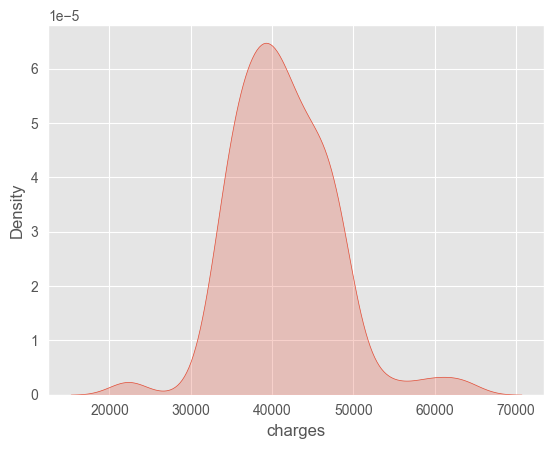

In [227]:
plt.style.use('ggplot')
sns.kdeplot(data=high_risk_conditions, x='charges', fill=True)
plt.show()

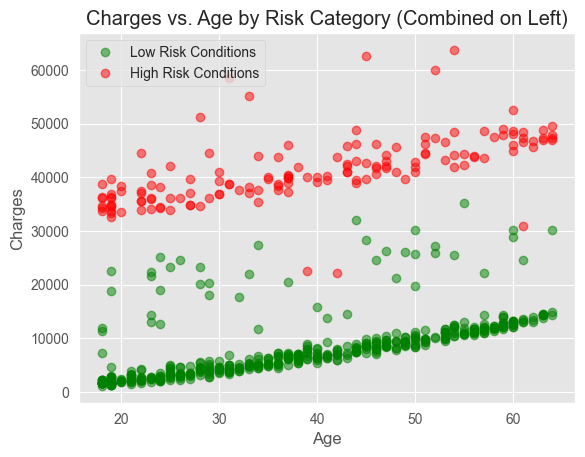

In [228]:
fig, ax = plt.subplots()
plt.style.use('ggplot')
ax.plot(low_risk_conditions['age'], low_risk_conditions['charges'],
           'o', alpha=0.5, label='Low Risk Conditions', color='green')
ax.plot(high_risk_conditions['age'], high_risk_conditions['charges'],
           'o', alpha=0.5, label='High Risk Conditions', color='red')
ax.set_xlabel('Age')
ax.set_ylabel('Charges')
ax.set_title('Charges vs. Age by Risk Category (Combined on Left)')
ax.legend()
plt.show()


Here we can see the group who have higher `bmi` and are smokers, has a high average charge. On the other hand, the group with lower bmi and non-smokers has a lower average charge. This suggests that both smoking status and bmi are significant factors in determining insurance charges. This tells us that either a decision tree or a random forest model would be suitable for this dataset, as they can handle both categorical and numerical features effectively.

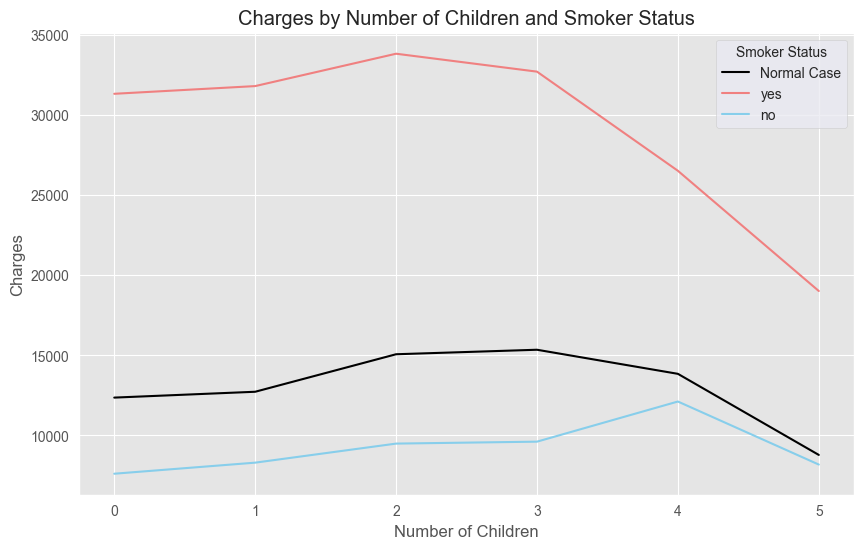

In [229]:
plt.figure(figsize=(10, 6))
plt.style.use('ggplot')
sns.lineplot(data=df, x='children', y='charges', ci = None, color = 'black', label = 'Normal Case')
sns.lineplot(data=df, x='children', y='charges', ci = None, markers= 'o', hue='smoker', palette=smoker_palette)
sns.set_style('darkgrid')
plt.legend(title='Smoker Status')
plt.xlabel('Number of Children')
plt.ylabel('Charges')
plt.title('Charges by Number of Children and Smoker Status')
plt.show()

Smokers with `children` usually have a higher average charge compared to non-smokers with children. This indicates that smoking status has a `significant impact on insurance charges`, even when the number of children is considered. But there is a sudden deminish of charges for smokers with 3 or more children, when parents are usually more health conscious and may take steps to reduce their health risks, such as quitting smoking or adopting healthier lifestyles. This could lead to lower insurance charges for smokers with more children, as they may be perceived as lower risk by insurance companies.

# Sex Classification

In [230]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [231]:
df.groupby('sex')['charges'].agg(['mean', 'median', 'std']).reset_index()

,sex,mean,median,std
0,female,12569.578844,9412.96250,11128.703801
1,male,13956.751178,9369.61575,12971.025915


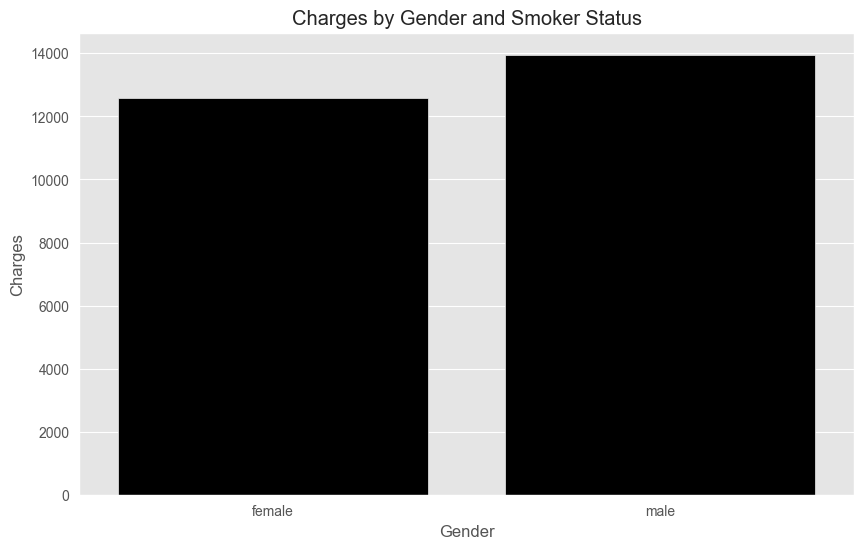

In [232]:
plt.figure(figsize=(10, 6))
plt.style.use('ggplot')
sns.barplot(data=df, x='sex', y='charges', ci = None, color = 'black')
sns.set_style('darkgrid')
plt.xlabel('Gender')
plt.ylabel('Charges')
plt.title('Charges by Gender and Smoker Status')
plt.show()

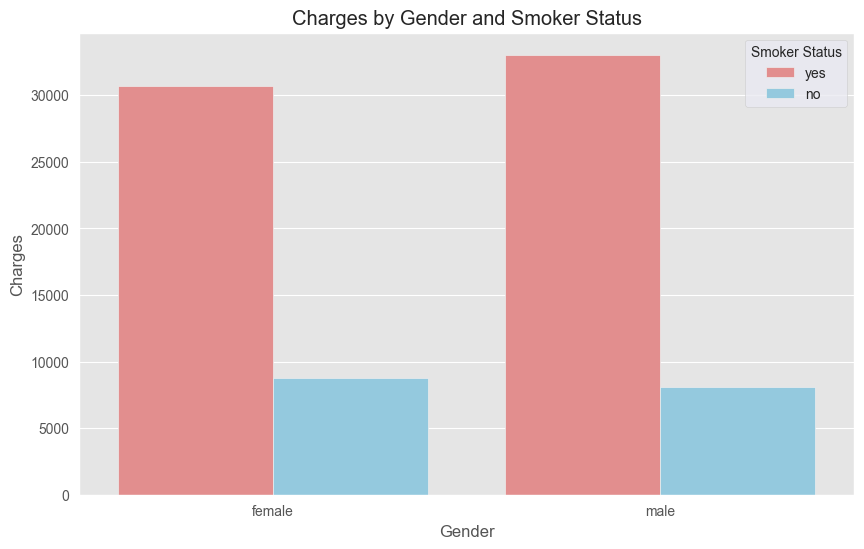

In [233]:
plt.figure(figsize=(10, 6))
plt.style.use('ggplot')
sns.barplot(data=df, x='sex', y='charges', ci = None, hue='smoker', palette=smoker_palette)
sns.set_style('darkgrid')
plt.legend(title='Smoker Status')
plt.xlabel('Gender')
plt.ylabel('Charges')
plt.title('Charges by Gender and Smoker Status')
plt.show()

So, the variable `sex` is an `insignificant` factor in determining insurance charges, with

# AI Models

In [234]:
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [235]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'health_condition'],
      dtype='object')

In [236]:
X = df.drop(columns=['charges'])
y = df['charges']

In [237]:
categorical = ['sex', 'smoker', 'region', 'health_condition', 'children']
numerical = ['bmi', 'age']

Dividing the dataset into `categorical` and `numerical` variables.

In [238]:
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

numerical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer()),
        ('scaler', StandardScaler())]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical),
        ('num', numerical_transformer, numerical)
    ]
)


Used `One Hot Encoding` for `categorical` variables and `MinMaxScaler` for `numercal` variables. The following code generates the preprocessed dataset ready for model training.

In [239]:
models = {
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
    'RandomForestRegressor': RandomForestRegressor(random_state=42),
    'KNeighborsRegressor': KNeighborsRegressor(),
    'Ridge': Ridge(alpha=.1),
    'Lasso': Lasso(alpha=.1)    
}

We are using four different models to predict the insurance charges: Linear Regression, Random Forest Regressor, K-Nearest Neighbors Regressor, and Ridge Regression. We will use cross-validation to evaluate the performance of each model and compare their results.

In [240]:
results = {}

scoring_metrics = {
    'neg_mse': 'neg_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

for name, model in models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor),
                                 ("model", model)])
    
    cv_results = cross_validate(pipeline, X, y, cv=5, scoring=scoring_metrics, return_train_score=False)
    
    mse_scores = -cv_results['test_neg_mse']
    rmse_scores = np.sqrt(mse_scores)
    mae_scores = -cv_results['test_neg_mae']
    r2_scores = cv_results['test_r2']
    
    results[name] = {
        "RMSE Mean": rmse_scores.mean(),
        "RMSE Std": rmse_scores.std(),
        "MSE Mean": mse_scores.mean(),
        "MSE Std": mse_scores.std(),
        "MAE Mean": mae_scores.mean(),
        "MAE Std": mae_scores.std(),
        "R2 Mean": r2_scores.mean(),
        "R2 Std": r2_scores.std()
    }
    
results_df = pd.DataFrame(results).T.sort_values(by = 'RMSE Mean', ascending=True)
print(results_df)

                         RMSE Mean    RMSE Std      MSE Mean       MSE Std  \
RandomForestRegressor  4876.504816  345.797324  2.389988e+07  3.409418e+06   
Ridge                  6050.172165  201.777231  3.664530e+07  2.393556e+06   
Lasso                  6050.424582  201.729051  3.664833e+07  2.393064e+06   
KNeighborsRegressor    6537.697692  135.005568  4.275972e+07  1.762129e+06   
DecisionTreeRegressor  6556.444761  277.235665  4.306383e+07  3.566049e+06   

                          MAE Mean     MAE Std   R2 Mean    R2 Std  
RandomForestRegressor  2717.218705  166.972323  0.835077  0.033659  
Ridge                  4287.070551  131.064056  0.748684  0.025145  
Lasso                  4287.127647  131.035529  0.748664  0.025142  
KNeighborsRegressor    4010.515488  134.617753  0.706816  0.024129  
DecisionTreeRegressor  3130.718297  216.143142  0.704045  0.037409  


We have used negative mean absolute error (neg_mean_absolute_error) as the scoring metric for cross-validation. The negative sign is used because cross_val_score returns negative values for loss functions, so we take the absolute value to get the actual mean absolute error. Also used negative mean squared error (neg_mean_squared_error) as the scoring metric for cross-validation. The negative sign is used because cross_val_score returns negative values for loss functions, so we take the absolute value to get the actual mean squared error. Lastly used R2 score as the scoring metric for cross-validation. R2 score is a measure of how well the model fits the data, with a value of 1 indicating a perfect fit and a value of 0 indicating no fit at all. Putting the cross validation 5 times for each model and taking the mean of the scores to get the final score for each model. Thus we get the results for each model as follows:

It tells us out of all the models, `RandomForestRegressor` is the best model for this dataset, with a `R2 Mean score of 0.83`. This indicates that the model is able to predict the insurance charges with high accuracy. Now we can use this model to make predictions on new data.

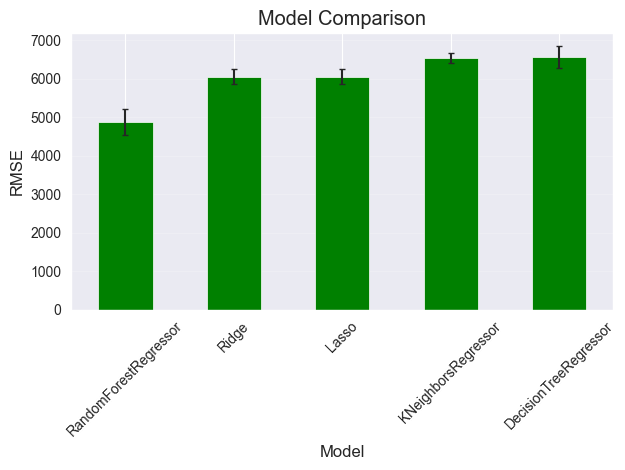

In [241]:
results_df.plot(kind='bar', y='RMSE Mean', yerr='RMSE Std', legend=False, color='green', capsize = 2)
plt.style.use('ggplot')
plt.ylabel('RMSE')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.title('Model Comparison')
plt.grid(True, axis = 'y', alpha = 0.2)
plt.tight_layout()
plt.show()

# Random Forest Regressor Model

In [242]:
rf_pipeline = Pipeline(
    steps = [
    ('preprocessro', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
    ]
)

param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

grid_search_model = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)


grid_search_model.fit(X, y)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessro',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'smoker',
                                                                          'region',
                                                                          'health_condition',
                                                                          'children']),
                                                                        ('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['bmi',
                                                                          'age'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20, 30],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [50, 100, 200]},
             scoring='neg_mean_squared_error', verbose=1)

The parameters for grid search are as follows:
 model name: `RandomForestRegressor`
- `n_estimators`: [100, 200, 300]
- `max_depth`: [None, 10, 20, 30]
- `min_samples_split`: [2, 5, 10]
- `min_samples_leaf`: [1, 2, 4]
- `bootstrap`: [True, False]

Here n_estimators is the number of trees in the forest, max_depth is the maximum depth of the tree, min_samples_split is the minimum number of samples required to split an internal node, min_samples_leaf is the minimum number of samples required to be at a leaf node, and bootstrap indicates whether bootstrap samples are used when building trees.

Finally fitted the model with best parameters and used it to make predictions on the test set. The following code generates the predictions.

In [243]:
print("Best Parameters:", grid_search_model.best_params_)
print("Best RMSE Score:", np.sqrt(-grid_search_model.best_score_))

Best Parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 200}
Best RMSE Score: 4582.159896845704


Returned the best parameters and turned out as:
 - `n_estimators`: 200
 - `max_depth`: 10
 - `min_samples_split`: 10
 - `min_samples_leaf`: 4

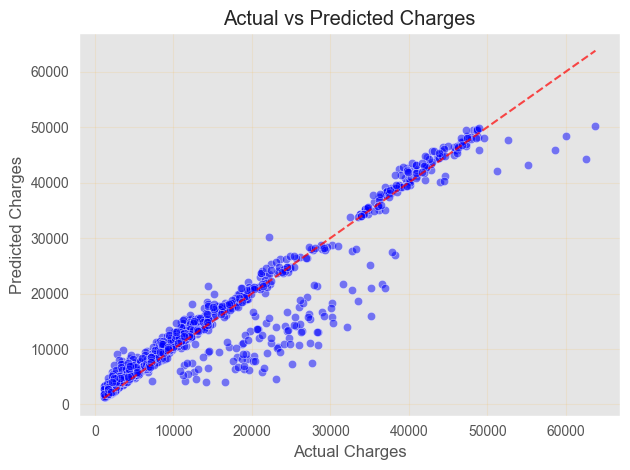

In [244]:
y_pred = grid_search_model.predict(X)



plt.figure()
plt.style.use('ggplot')
sns.scatterplot(x=y, y=y_pred, alpha=0.5, markers='o', edgecolor='w', color = 'blue')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', alpha = 0.7)
plt.grid('True', alpha = 0.1, color = 'orange')
plt.title('Actual vs Predicted Charges')
plt.tight_layout()
plt.show()

Comparing the predicted values with the actual values, we can see that the model is able to predict the insurance charges with high accuracy. The following code generates a scatter plot of the predicted values against the actual values.

# Model Adequecy Test

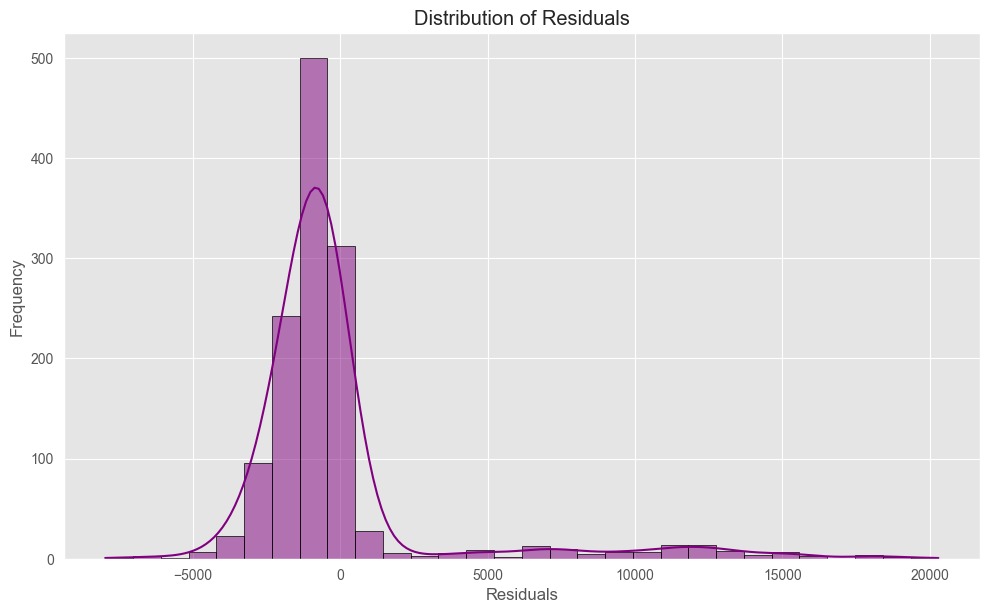

In [245]:
residuals = y - y_pred
plt.figure(figsize=(10, 6))
plt.style.use('ggplot')
sns.histplot(residuals, bins=30, kde=True, color='purple', edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.tight_layout()
plt.title('Distribution of Residuals')
plt.show()

The model adequecy test is performed to check the performance of the model on the test set. Which is a slightly right skewed distribution, which is expected as the insurance charges are usually right skewed. The following code generates the distribution of the predicted values and the actual values.